# Labo 3 - First experiment

## Concat data sets

In [53]:
import pandas as pd

mouse_ds1 = pd.read_csv('./labo3/EEG_mouse_data_1.csv')
mouse_ds2 = pd.read_csv('./labo3/EEG_mouse_data_2.csv')
test_ds = pd.read_csv('./labo3/EEG_mouse_data_test.csv')

data_set = pd.concat([mouse_ds1, mouse_ds2])

#print('Shape:', data_set.shape)
#print(data_set.head())



## Displaying features

In [54]:
feature_list = [f'amplitude_around_{i}_Hertz' for i in range(1, 26)]

features = data_set[feature_list].copy()
# binary targets -> awake = 1 and asleep = 0
states = (data_set['state'] == 'w').astype(int).values


#print(data_set['state'].value_counts())
#print()
#print(features.head())

## Normalization

In [55]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
# fit_transform -> compute mean and std for each feature
features_scaled = scaler.fit_transform(X)

print("Mean of first feature :", features_scaled[:, 0].mean().round(4))
print("Std of first feature :", features_scaled[:, 0].std().round(4))

Mean of first feature : 0.0
Std of first feature : 1.0


## DEfining model

In [56]:
import keras
from keras import layers

def create_model():
    model = keras.Sequential([
        # number of features
        layers.Input(shape=(25,)),
        # 16 neurones in hidden layer
        layers.Dense(16, activation='tanh'),
        # unique outpu
        # > 0.5 -> awake and < 0.5 -> asleep
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        # momentum to help not get stuck in local minuma
        optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        loss='mse',
        metrics=['accuracy']
    )
    return model

# Display model summary
create_model().summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 16)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433 (1.69 KB)

 Trainable params: 433 (1.69 KB)

 Non-trainable params: 0 (0.00 B)

## 3-Fold cross validation

In [57]:
from sklearn.model_selection import KFold

# seed for reproductibility
keras.utils.set_random_seed(23)

# 3-Fold
kf = KFold(n_splits=3, shuffle=True, random_state=23)

# list for each fold
history_list = []
trained_models = []
fold_indices = []

for fold, (train_idx, val_idx) in enumerate(kf.split(features_scaled)):
    print(f"\n--- Fold {fold + 1} ---")

    # split for training and validation
    x_train, x_val = features_scaled[train_idx], features_scaled[val_idx]
    y_train, y_val = states[train_idx], states[val_idx]

    # new model for each fold
    model = create_model()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=30,
        batch_size=64,
        verbose=0
    )

    history_list.append(history)
    trained_models.append(model)
    fold_indices.append((train_idx, val_idx))

    print(f"Final value loss: {history.history['val_loss'][-1]:.4f}")


--- Fold 1 ---
Final value loss: 0.0856

--- Fold 2 ---
Final value loss: 0.0817

--- Fold 3 ---
Final value loss: 0.0857


## Plot training history

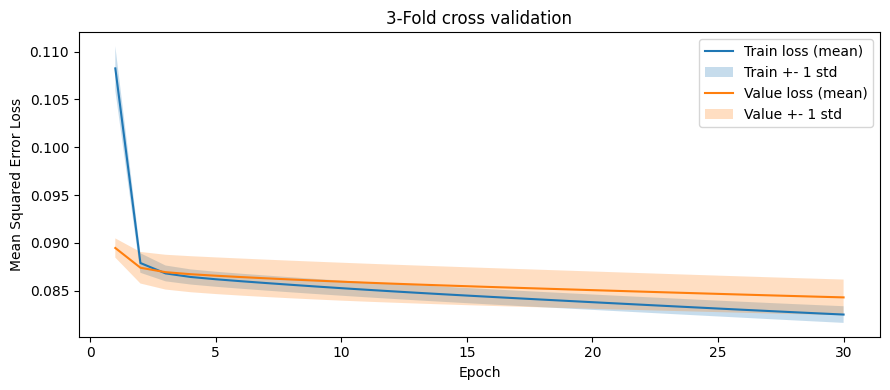

In [59]:
import matplotlib.pyplot as plt
%matplotlib inline

# all losses from all 3 folds
train_losses = np.array([h.history['loss'] for h in history_list])
value_losses = np.array([h.history['val_loss'] for h in history_list])

# average between folds -> get one curve
mean_train = train_losses.mean(axis=0)
std_train = train_losses.std(axis=0)
mean_val = value_losses.mean(axis=0)
std_val = value_losses.std(axis=0)

epochs = range(1, len(mean_train) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochs, mean_train, label='Train loss (mean)')
# shows training stability
plt.fill_between(epochs, mean_train - std_train, mean_train + std_train, alpha=0.25, label='Train +- 1 std')
plt.plot(epochs, mean_val, label='Value loss (mean)')
plt.fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.25, label='Value +- 1 std')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('3-Fold cross validation')
plt.legend()
plt.tight_layout()
plt.show()

## Confusion matrix + F-1 score

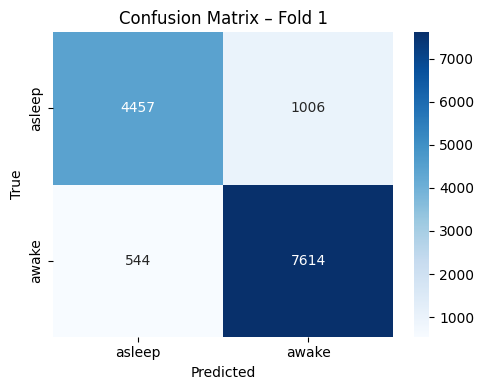

Fold 1 — F1 awake: 0.908 | F1 asleep: 0.852



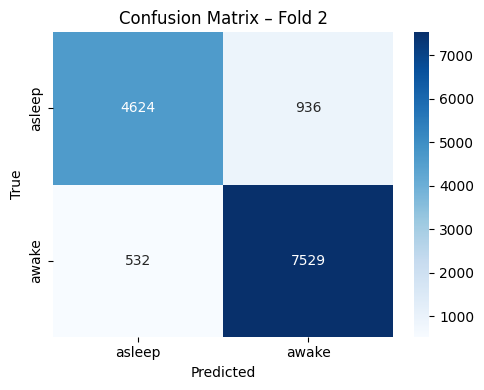

Fold 2 — F1 awake: 0.911 | F1 asleep: 0.863



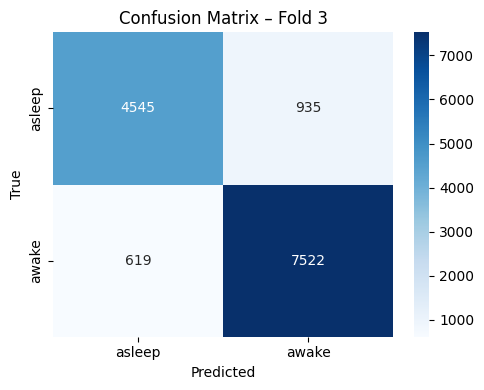

Fold 3 — F1 awake: 0.906 | F1 asleep: 0.854

Global confusion matrix (all folds)


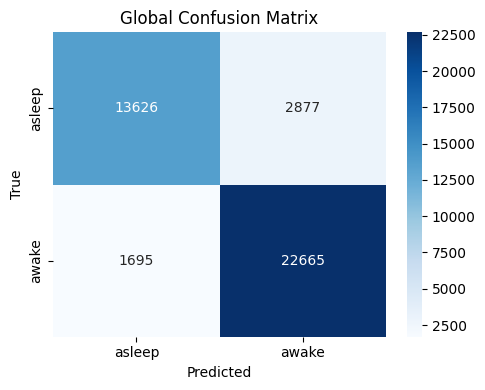

In [62]:
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns

def plot_cm(cm, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['asleep', 'awake'],
                yticklabels=['asleep', 'awake'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

f1_scores = []
global_cm = np.zeros((2, 2), dtype=int)

for fold, (train_idx, val_idx) in enumerate(fold_indices):
    # probability between 0 and 1
    preds_prob = trained_models[fold].predict(features_scaled[val_idx], verbose=0)
    # > 0.5 predicted as awake
    # <= 0.5 predicted as aleep
    preds = (preds_prob.flatten() > 0.5).astype(int)
    true  = states[val_idx]

    cm = confusion_matrix(true, preds)
    global_cm += cm
    plot_cm(cm, f'Confusion Matrix – Fold {fold + 1}')

    # F1 per class -> balance between precision and recall
    f1_awake  = f1_score(true, preds, pos_label=1)
    f1_asleep = f1_score(true, preds, pos_label=0)

    print(f"Fold {fold+1} — F1 awake: {f1_awake:.3f} | F1 asleep: {f1_asleep:.3f}\n")

print("Global confusion matrix (all folds)")
plot_cm(global_cm, 'Global Confusion Matrix')